## **Google Colab**

<td>
<a target="_blank" href="https://colab.research.google.com/github/ahiqal/ML/blob/main/Deep%20Learning/CWRU%20bearing%20fault%20diagnosis%20with%20CNN-Transformer/CWRU%20bearing%20fault%20diagnosis%20with%20CNN-Transformer.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
</td>

Please use Google Colab for more convenient navigation to any section of this notebook (via a Table of Contents).

## Overview

Objective:

* Build a model to classify bearing health states from raw 1D vibration signals






Motivation:

* Failures in rolling-element bearings are a leading cause of unplanned downtime in rotating machinery. The key challenge in condition monitoring and predictive maintenance is catching these faults early by analyzing vibration signals before they grow into serious failures.
* Working with raw vibration signals for bearing fault diagnosis is challenging because the data is noisy, complex, and changes over time.
* Convolutional Neural Networks (CNNs) are good at extracting local features and patterns from raw signals. But, CNNs tend to focus on short-range patterns and often miss relationships over longer parts of the signal.
* Transformers complement the CNNs by operating on the sequence of CNN feature tokens and applying self-attention across them. The self-attention mechanism determines which tokens carry the useful information and how they relate, allowing the tokens to exchange information and be refined before classification.
* Combining CNNs and Transformers is a logical approach. One handles local feature extraction, and the other looks across the token sequence to figure out how those features relate.
* The goal is to build a model that is both more accurate and more reliable across different types of faults.


Dataset:

*   Case Western Reserve University (CWRU) bearing dataset


## Imports

In [68]:
import os
import requests

import scipy.io
import scipy.signal
from scipy.stats import kurtosis, skew

import matplotlib.pyplot as plt
import seaborn as sns

import math
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch import optim

## Data (.mat)


In [69]:
MAT_MAP = {
    100: {"label": "Healthy", "name": "Normal_3"},
    108: {"label": "Inner race", "name": "IR007_3"},
    121: {"label": "Ball", "name": "B007_3"},
    133: {"label": "Outer race", "name": "OR007@6_3"},
    147: {"label": "Outer race", "name": "OR007@3_3"},
    160: {"label": "Outer race", "name": "OR007@12_3"},
}

- Six recordings from the CWRU dataset are used, all from the **drive-end (DE)
accelerometer** at **12 kHz** sampling, **1730 RPM** motor speed (3 HP load),
**0.007″ fault diameter**. <br>

- They are treated as the same class, but only one (`OR007@12_3`) is used for model training, the others appear in EDA for comparison.

### Normal baseline data and bearing fault data

In [70]:
def download_mat_cwru(mat_map):
    for key, value in mat_map.items():
        url = f"https://engineering.case.edu/sites/default/files/{key}.mat"
        r = requests.get(url)
        name = f"{key}_{value['name']}"
        with open(f"{name}.mat", "wb") as f:
            f.write(r.content)

download_mat_cwru(MAT_MAP)

In [71]:
def load_mat_cwru(id, mat_map):
  value =  mat_map[id]
  if value:
    return scipy.io.loadmat(f"{id}_{value['name']}.mat")
  else:
    return None

In [72]:
mat_0 = load_mat_cwru(100, MAT_MAP)
mat_0

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Fri Jan 28 11:25:48 2000',
 '__version__': '1.0',
 '__globals__': [],
 'X100_DE_time': array([[ 0.01460308],
        [ 0.05444862],
        [ 0.10764554],
        ...,
        [-0.02357354],
        [ 0.00521538],
        [ 0.04777292]]),
 'X100_FE_time': array([[ 0.19292182],
        [ 0.16436364],
        [ 0.09081091],
        ...,
        [ 0.10930182],
        [ 0.05218545],
        [-0.00452   ]]),
 'X100RPM': array([[1725]], dtype=uint16)}

In [73]:
mat_1 = load_mat_cwru(108, MAT_MAP)
mat_1

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 31 15:17:29 2000',
 '__version__': '1.0',
 '__globals__': [],
 'X108_DE_time': array([[ 0.22269856],
        [ 0.09323776],
        [-0.14651649],
        ...,
        [-0.36125573],
        [ 0.31138814],
        [ 0.17055689]]),
 'X108_FE_time': array([[-0.09738545],
        [-0.1808    ],
        [-0.23360182],
        ...,
        [ 0.12265636],
        [ 0.02177818],
        [-0.00143818]]),
 'X108_BA_time': array([[ 0.07741674],
        [-0.00241424],
        [-0.06212653],
        ...,
        [ 0.22545009],
        [ 0.2301981 ],
        [ 0.16424902]]),
 'X108RPM': array([[1721]], dtype=uint16)}

In [74]:
mat_2 = load_mat_cwru(121, MAT_MAP)
mat_3 = load_mat_cwru(133, MAT_MAP)
mat_4 = load_mat_cwru(147, MAT_MAP)
mat_5 = load_mat_cwru(160, MAT_MAP)

In [75]:
MAT_ALIAS_MAP = {
    "mat_0": 100,
    "mat_1": 108,
    "mat_2": 121,
    "mat_3": 133,
    "mat_4": 147,
    "mat_5": 160,
}

### Keys

In [76]:
print(mat_0.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X100_DE_time', 'X100_FE_time', 'X100RPM'])


In [77]:
print(mat_1.keys())
print(mat_2.keys())
print(mat_3.keys())
print(mat_4.keys())
print(mat_5.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X108_DE_time', 'X108_FE_time', 'X108_BA_time', 'X108RPM'])
dict_keys(['__header__', '__version__', '__globals__', 'X121_DE_time', 'X121_FE_time', 'X121_BA_time', 'X121RPM'])
dict_keys(['__header__', '__version__', '__globals__', 'X133_DE_time', 'X133_FE_time', 'X133_BA_time', 'X133RPM'])
dict_keys(['__header__', '__version__', '__globals__', 'X147_DE_time', 'X147_FE_time', 'X147_BA_time', 'X147RPM'])
dict_keys(['__header__', '__version__', '__globals__', 'X160_DE_time', 'X160_FE_time', 'X160_BA_time', 'X160RPM'])


- All `.mat` files contain a `DE_time` field (the **drive-end accelerometer** time-domain signal), sampled at 12 kHz. Only `DE_time` is used from here on.

## EDA

### Statistical feature

In [78]:
mats = [mat_0, mat_1, mat_2, mat_3, mat_4, mat_5]

In [79]:
raw_data = {}
for m in mats:
  for key in m:
      if 'DE_time' in key:
          raw_data[key] = m[key].flatten()

raw_data

{'X100_DE_time': array([ 0.01460308,  0.05444862,  0.10764554, ..., -0.02357354,
         0.00521538,  0.04777292]),
 'X108_DE_time': array([ 0.22269856,  0.09323776, -0.14651649, ..., -0.36125573,
         0.31138814,  0.17055689]),
 'X121_DE_time': array([ 0.09031393,  0.22497265, -0.10883154, ...,  0.02858858,
        -0.15934886, -0.01835517]),
 'X133_DE_time': array([-0.10842545, -0.12710549,  0.09867934, ..., -0.24446487,
         0.13969421,  0.02883224]),
 'X147_DE_time': array([ 0.10436457,  0.62537525,  0.12304461, ...,  0.88689581,
         0.84588094, -0.5636499 ]),
 'X160_DE_time': array([ 0.16438435,  0.21506411, -0.22497265, ...,  0.01120802,
        -0.12507505, -0.02826371])}

In [80]:
def compute_statistics(raw_data):
    data = raw_data.flatten()
    rms = np.sqrt(np.mean(data**2))
    max_val = np.max(data)
    min_val = np.min((data))
    max_abs = np.max(np.abs(data))

    return {
        "Mean": np.mean(data),
        "Std": np.std(data),
        "Max": max_val,
        "Min": min_val,
        "Absolute Max": max_abs,
        "RMS": rms,
        "Kurtosis": kurtosis(data),
        "Skewness": skew(data),
        "Crest Factor": max_abs / rms,
        "Samples": len(data),
    }

In [81]:
rows = []

for (num, info), (key, data) in zip(MAT_MAP.items(), sorted(raw_data.items())):
    row = {"Data": f"{key} - {info['name']}"}
    row.update(compute_statistics(data))
    rows.append(row)

df_stats = pd.DataFrame(rows)
df_stats

,Data,Mean,Std,Max,Min,Absolute Max,RMS,Kurtosis,Skewness,Crest Factor,Samples
0,X100_DE_time - Normal_3,0.012459,0.064695,0.283717,-0.306456,0.306456,0.065884,-0.042831,-0.127530,4.651457,485643
1,X108_DE_time - IR007_3,0.004718,0.313571,1.671457,-1.535499,1.671457,0.313607,2.291053,-0.013220,5.329788,122917
2,X121_DE_time - B007_3,0.004200,0.153577,0.671507,-0.720562,0.720562,0.153635,-0.110270,0.020412,4.690096,121556
3,X133_DE_time - OR007@6_3,0.004529,0.580377,3.236114,-3.003019,3.236114,0.580395,4.963746,-0.002107,5.575709,122571
4,X147_DE_time - OR007@3_3,0.006674,0.797570,3.619055,-3.316113,3.619055,0.797598,1.090259,0.083365,4.537440,122281
5,X160_DE_time - OR007@12_3,0.003791,0.256169,1.686402,-1.907151,1.907151,0.256197,5.289778,-0.039498,7.444092,122136


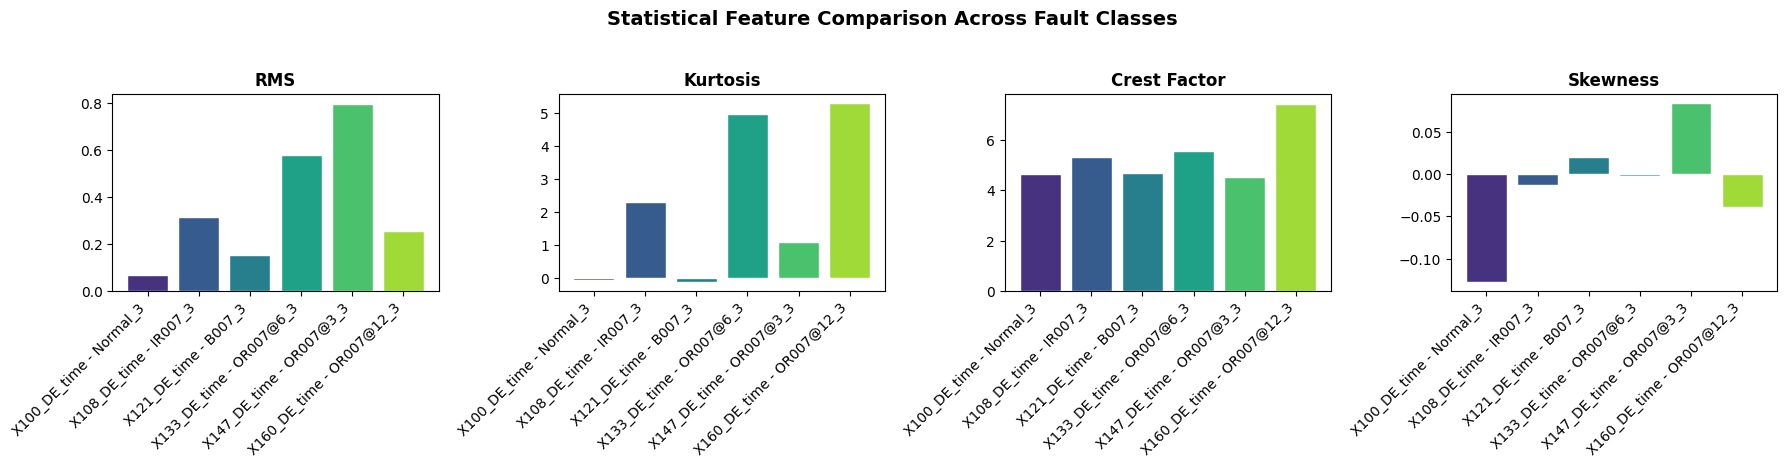

In [82]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
metrics = ["RMS", "Kurtosis", "Crest Factor", "Skewness"]
colors = sns.color_palette("viridis", len(df_stats['Data']))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(df_stats['Data'], df_stats[metric], color=colors, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_xticks(range(len(df_stats['Data'])))
    ax.set_xticklabels(df_stats['Data'], rotation=45, ha="right")

fig.suptitle("Statistical Feature Comparison Across Fault Classes",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

- "Kurtosis" and "Crest Factor" cleanly separate **healthy from faulted**, but do not separate the **fault types from each other**.
Simple statistics are sufficient for fault detection but not fault **classification**, which motivates the deep model in the rest of the notebook.

In [83]:
lengths = {}

for (num, j), (key, data) in zip(MAT_MAP.items(), sorted(raw_data.items())):
  lengths[f"{key} - {j['name']}"] = len(data)

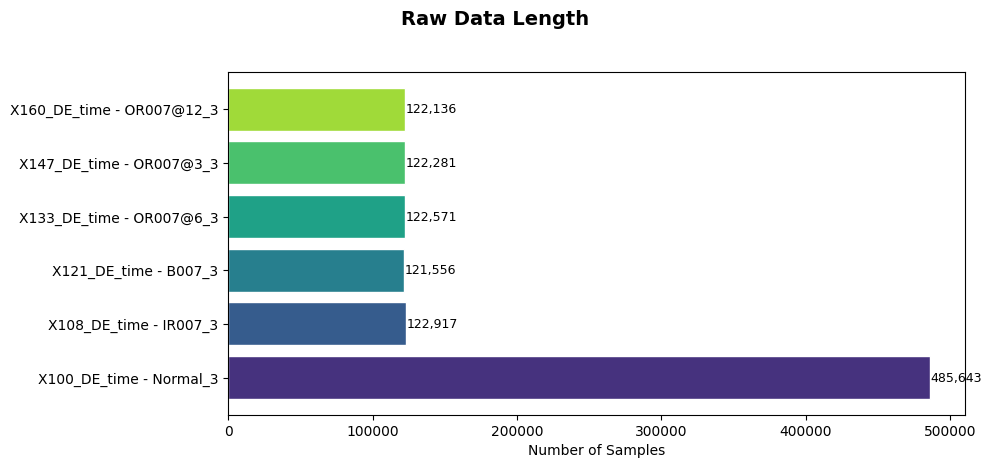

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
colors = sns.color_palette("viridis", len(lengths))

bars = ax.barh(list(lengths.keys()), list(lengths.values()), color=colors, edgecolor="white")
ax.set_xlabel("Number of Samples")
for bar, v in zip(bars, lengths.values()):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f"{v:,}", ha="left", va="center", fontsize=9)

fig.suptitle("Raw Data Length", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### Data distributions

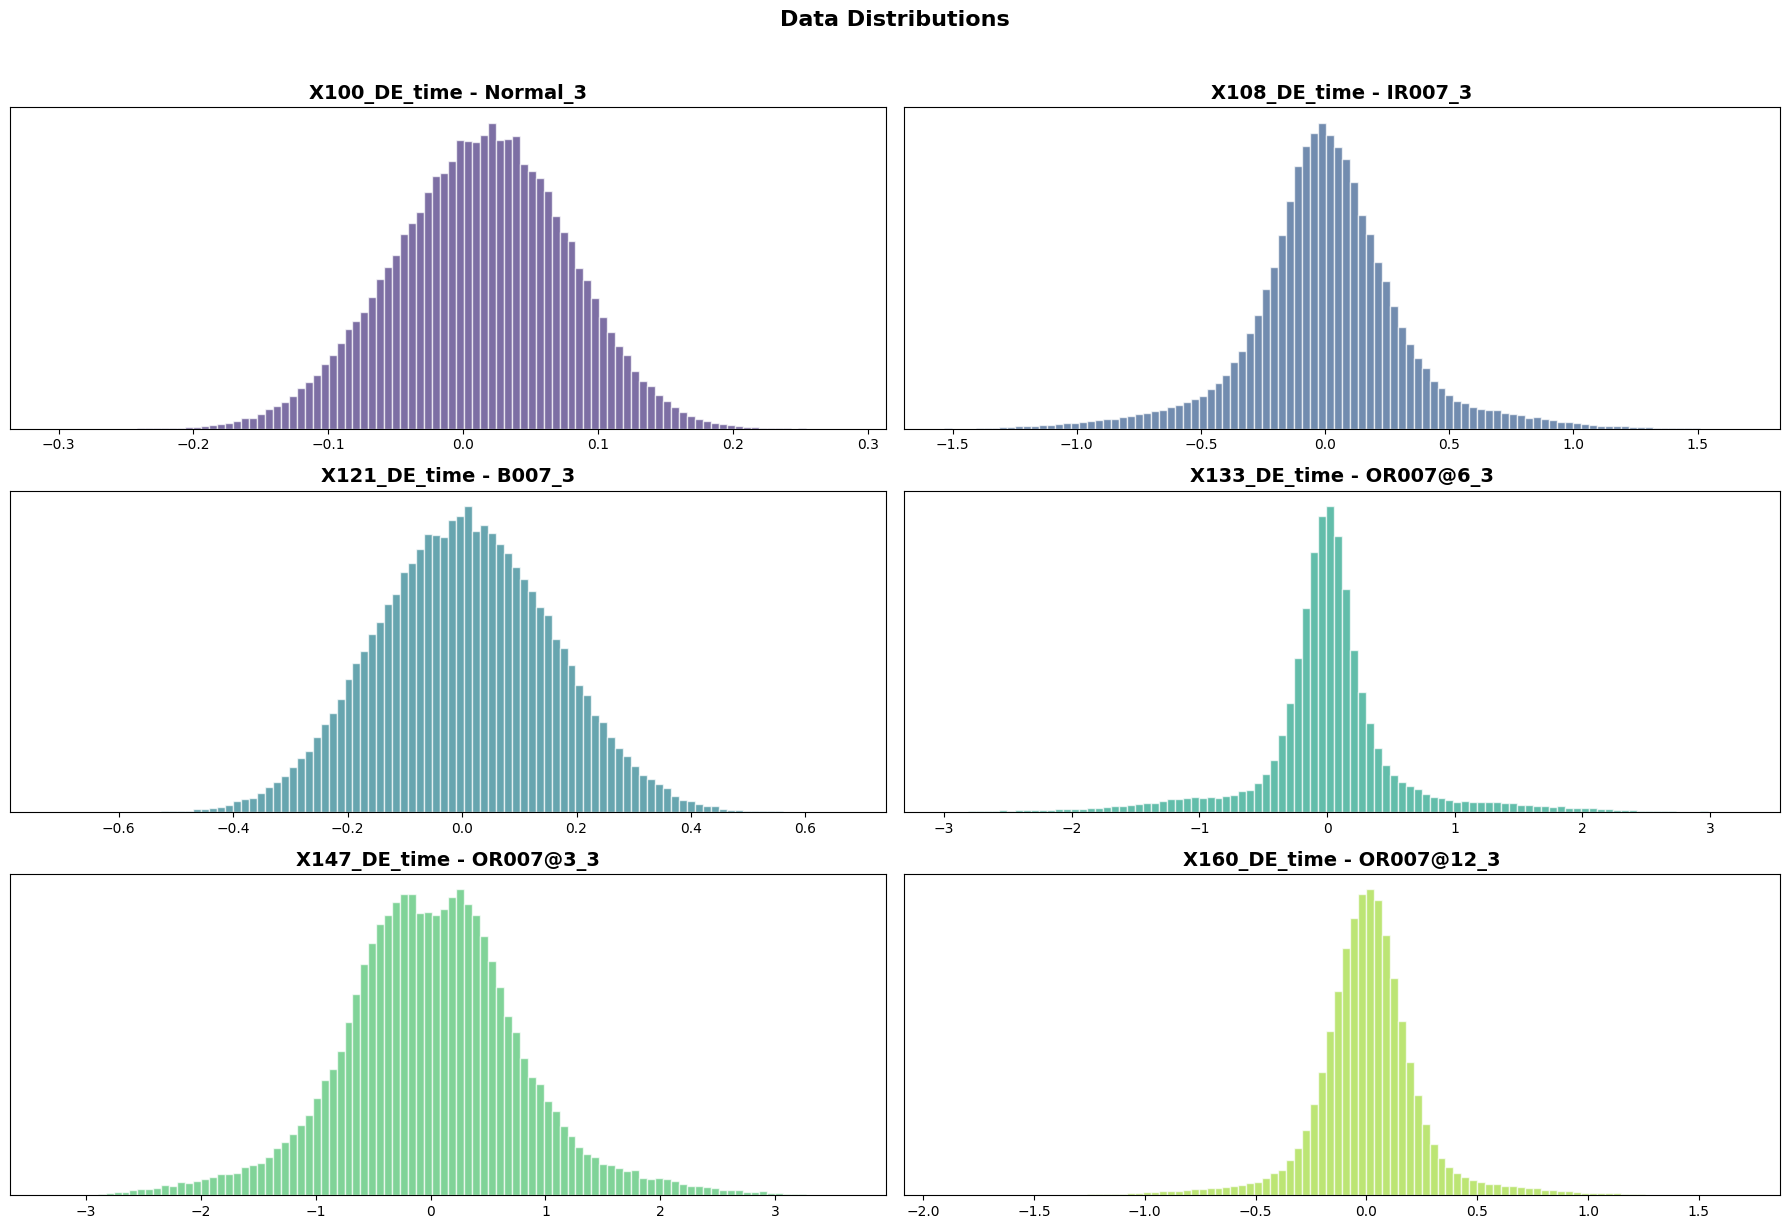

In [85]:
fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex=False)
axes = axes.flatten()
colors = sns.color_palette("viridis")

for (_, info), (idx, (key, data)) in zip(MAT_MAP.items(), enumerate(sorted(raw_data.items()))):
    ax = axes[idx]
    ax.hist(data, bins=100, density=True, alpha=0.7, color=colors[idx], edgecolor="white")
    ax.set_title(f"{key} - {info['name']}", fontsize=14, fontweight="bold")
    ax.set_yticks([])

fig.suptitle("Data Distributions",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

- All six distributions are centered near zero. Per-window z-score normalization (applied later) is appropriate for all classes. <br>

- **`Normal_3` is approximately Gaussian** — symmetric, bell-shaped, light tails. Healthy vibration behaves like broadband mechanical noise, as expected.

### Raw waveform

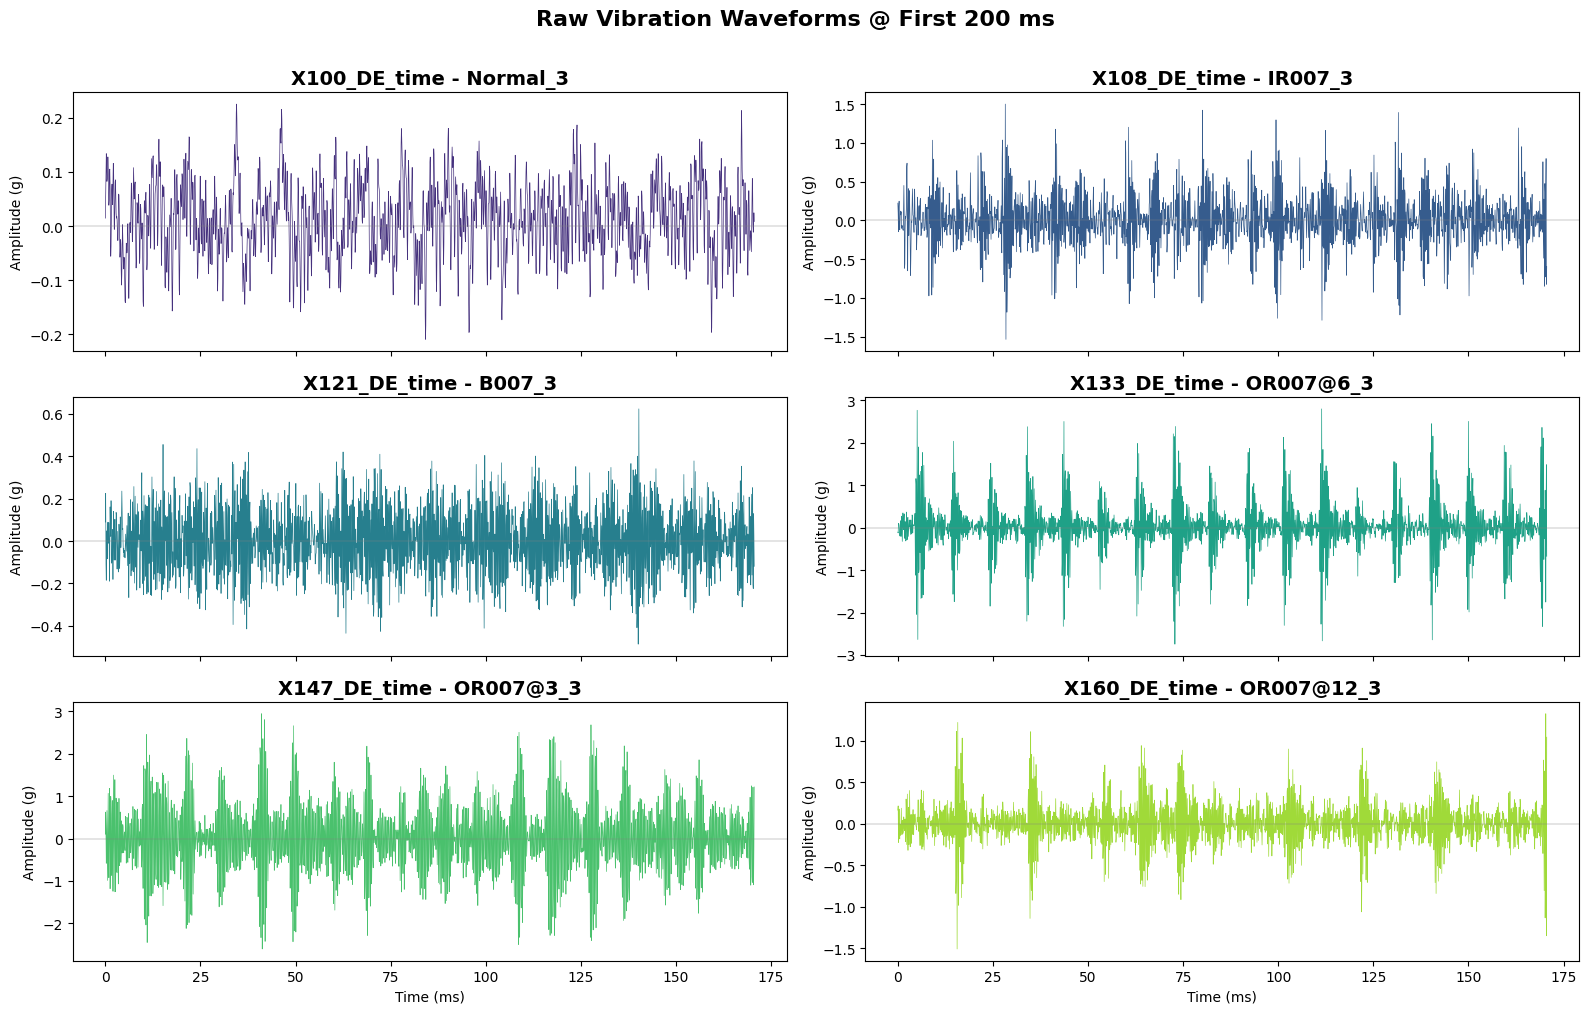

In [86]:
SAMPLE_LENGTH = 2048
SAMPLING_RATE = 12000

time_axis = np.arange(SAMPLE_LENGTH) / SAMPLING_RATE * 1000

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()
colors = sns.color_palette("viridis")

for (_, info), (idx, (key, data)) in zip(MAT_MAP.items(), enumerate(sorted(raw_data.items()))):
    ax = axes[idx]
    ax.plot(time_axis, data[:SAMPLE_LENGTH], linewidth=0.5, color=colors[idx])
    ax.set_title(f"{key} - {info['name']}", fontsize=14, fontweight="bold")
    ax.set_ylabel("Amplitude (g)")
    ax.axhline(0, color="gray", linewidth=0.3)

axes[-2].set_xlabel("Time (ms)")
axes[-1].set_xlabel("Time (ms)")
fig.suptitle("Raw Vibration Waveforms @ First 200 ms",
             fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

### Raw waveforms — first 200 ms

- Healthy signals are low-amplitude and noise-like. Faulted signals show **periodic impacts** as the rolling element passes the defect.

### Power Spectral Density (PSD)

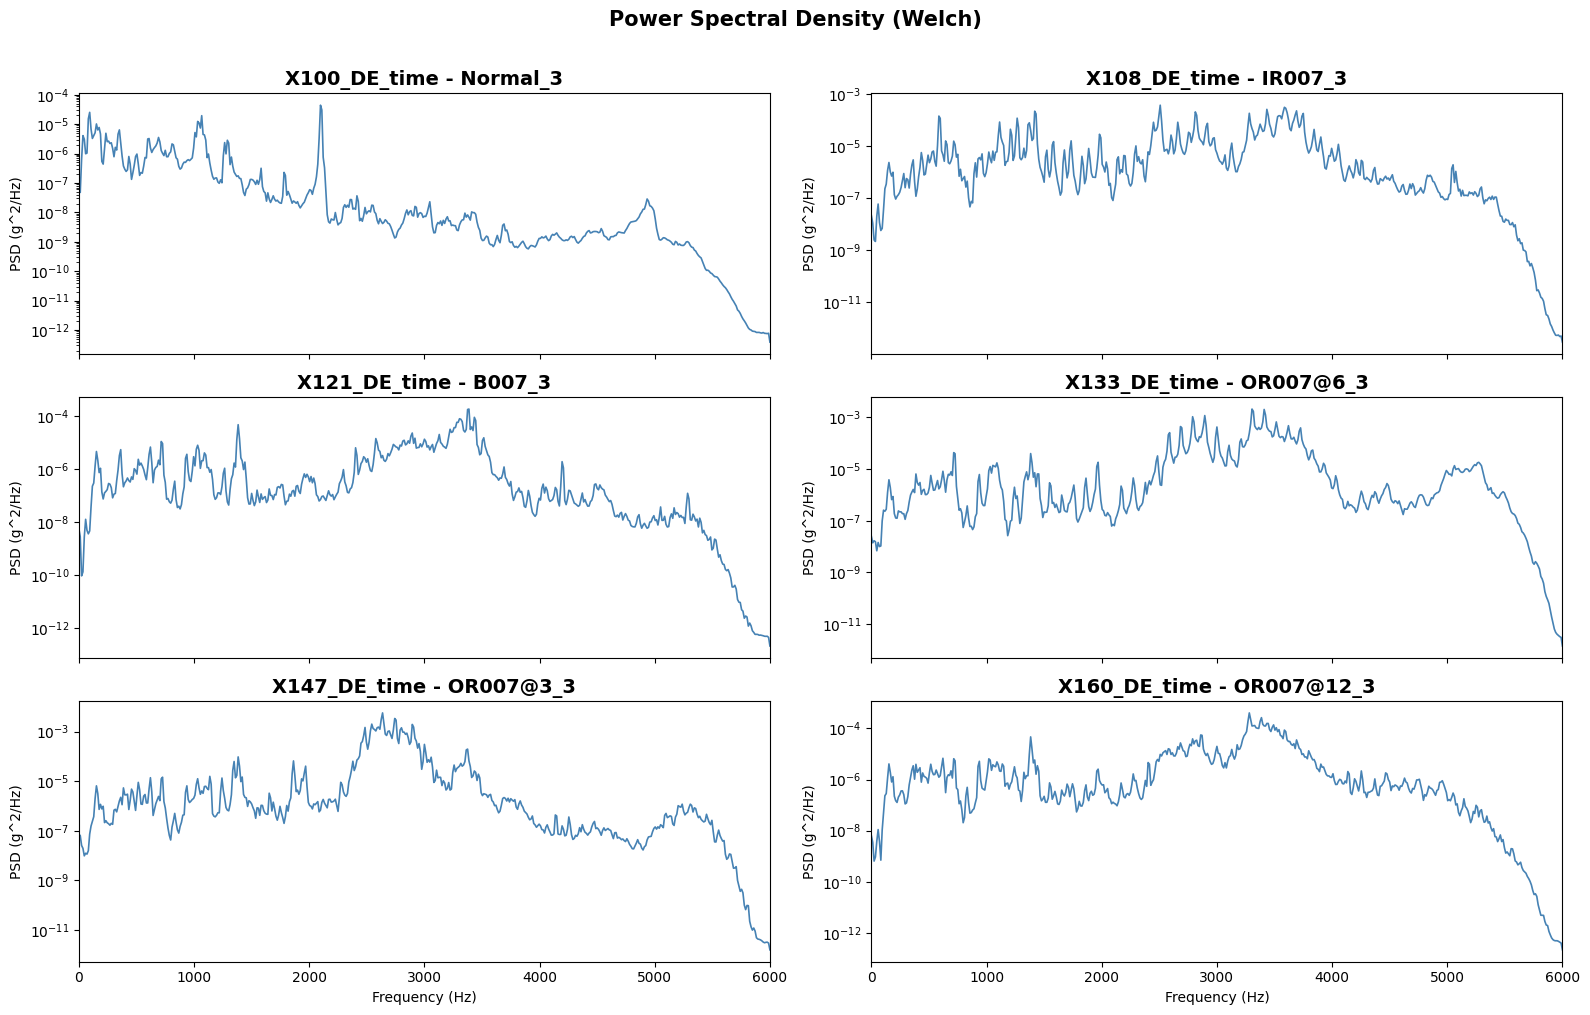

In [87]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for (_, info), (idx, (key, data)) in zip(MAT_MAP.items(), enumerate(sorted(raw_data.items()))):
    ax = axes[idx]
    freqs, psd = scipy.signal.welch(data, fs=SAMPLING_RATE, nperseg=1024)
    ax.semilogy(freqs, psd, linewidth=1.2, color="steelblue")
    ax.set_title(f"{key} - {info['name']}", fontsize=14, fontweight="bold")
    ax.set_ylabel("PSD (g^2/Hz)")
    ax.set_xlim(0, 6000)

axes[-1].set_xlabel("Frequency (Hz)")
axes[-2].set_xlabel("Frequency (Hz)")
fig.suptitle("Power Spectral Density (Welch)",
             fontsize=15, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

### Short-Time Fourier Transform (STFT) spectograms

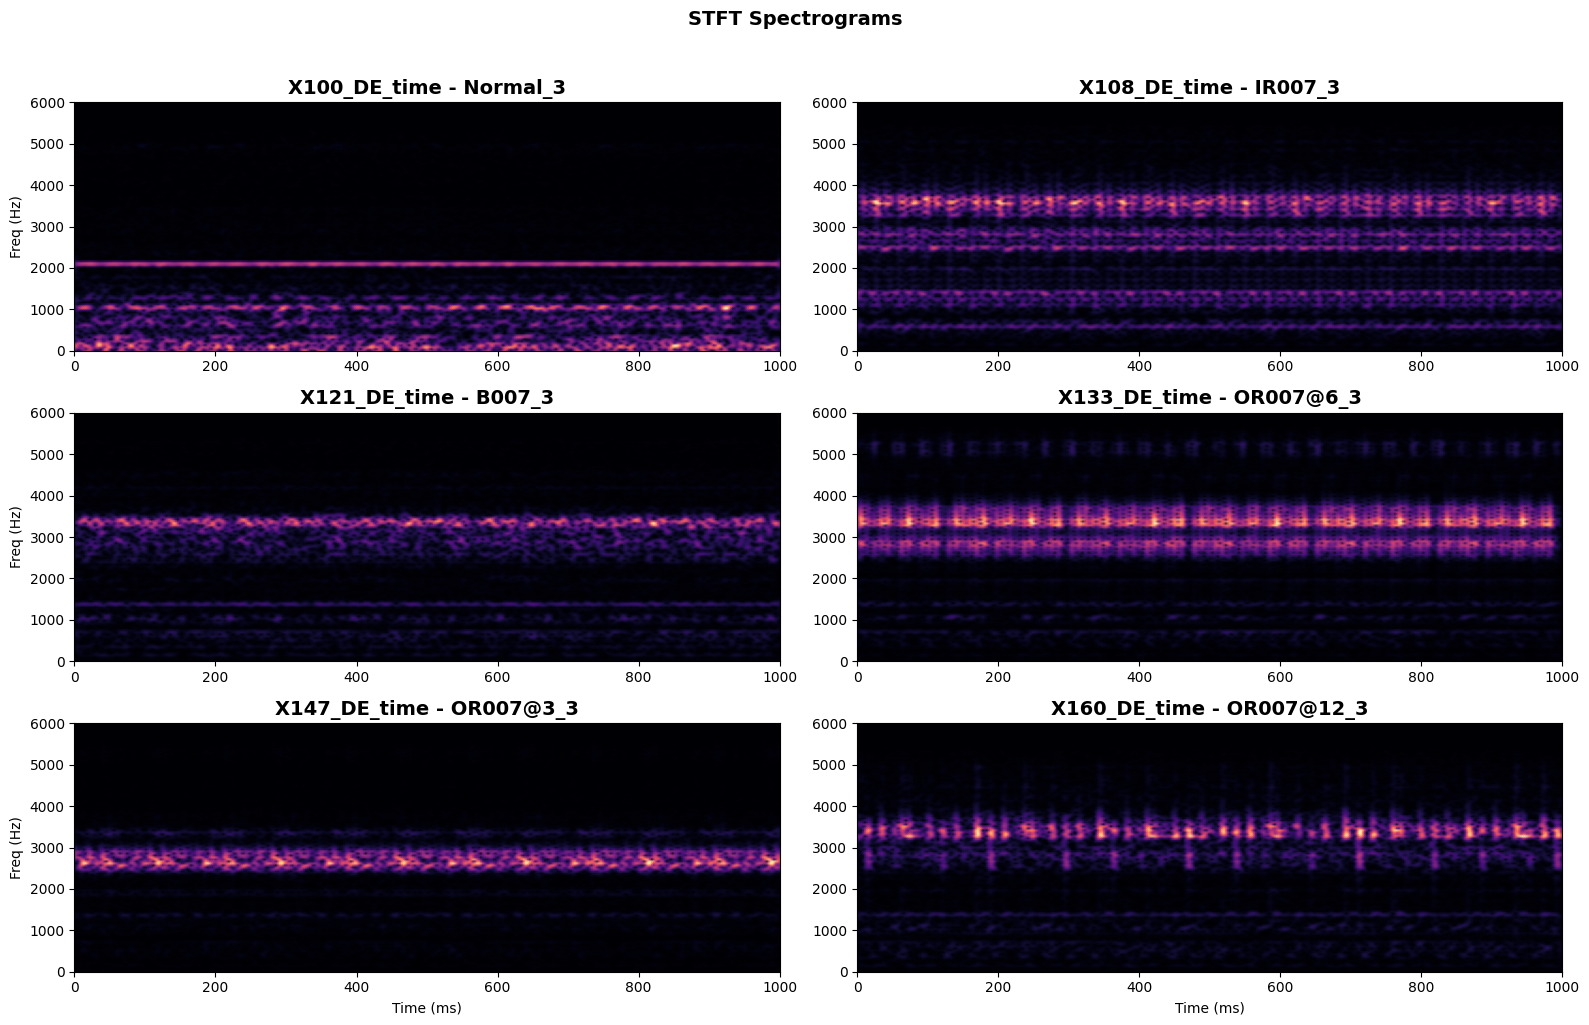

In [88]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

for (_, info), (idx, (key, data)) in zip(MAT_MAP.items(), enumerate(sorted(raw_data.items()))):
  ax = axes[idx]
  f, t, Zxx = scipy.signal.stft(data[:12000], fs=SAMPLING_RATE, nperseg=256, noverlap=224)
  ax.pcolormesh(t * 1000, f, np.abs(Zxx), shading="gouraud", cmap="magma")
  ax.set_title(f"{key} - {info['name']}", fontsize=14, fontweight="bold")

  ax.set_ylim(0, 6000)
  if idx >= 4:
    ax.set_xlabel("Time (ms)")
  if idx % 2 == 0:
    ax.set_ylabel("Freq (Hz)")

fig.suptitle("STFT Spectrograms",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

- The vibration energy is concentrated in the **2–4 kHz band** across all faulted classes.

### Envelope Spectrum

- Drive End Bearing <br>
- Name: 6205-2RS JEM SKF <br>
- Type: Deep groove ball bearing <br>

In [89]:
INSIDE_DIAMETER = 0.9843 # inches
OUTSIDE_DIAMETER = 2.0472 # inches
THICKNESS = 0.5906 # inches
BALL_DIAMETER = 0.3126 # inches
PITCH_DIAMETER = 1.537 # inches
CONTACT_ANGLE = 0.0 # degrees (deep groove ball bearing - pure radial load)
NUM_OF_BALLS = 9

MOTOR_SPEED = 1730 # RPM
RUNNING_FREQUENCY = MOTOR_SPEED / 60 # Hz

In [90]:
DEFECT_FREQUENCIES = {
    "BPFI": {"label": "Inner Race", "value": 5.4152}, # for BPFI (Ball Pass Frequency Inner)
    "BPFO": {"label": "Outer Race", "value": 3.5848}, # for BPFO (Ball Pass Frequency Outer)
    "BSF": {"label": "Ball", "value": 4.7135}, # for BSF (Ball Spin Frequency)
    "FTF": {"label": "Cage", "value": 0.39828}, # FTF (Fundamental Train Frequency)
}

In [91]:
def bpfi(
    f_r = RUNNING_FREQUENCY,
    n = NUM_OF_BALLS,
    d = BALL_DIAMETER,
    D = PITCH_DIAMETER,
    theta = CONTACT_ANGLE
):
    cphi = math.cos(math.radians(theta))

    return 0.5 * n * f_r * (1.0 + (d / D) * cphi)

In [92]:
def bpfo(
    f_r = RUNNING_FREQUENCY,
    n = NUM_OF_BALLS,
    d = BALL_DIAMETER,
    D = PITCH_DIAMETER,
    theta = CONTACT_ANGLE
):
  cphi = math.cos(math.radians(theta))

  return 0.5 * n * f_r * (1.0 - (d / D) * cphi)

In [93]:
def bsf(
    f_r = RUNNING_FREQUENCY,
    d = BALL_DIAMETER,
    D = PITCH_DIAMETER,
    theta = CONTACT_ANGLE
):
  cphi = math.cos(math.radians(theta))

  return 0.5 * (D / d) * f_r * (1.0 - (d / D) ** 2 * cphi ** 2)

In [94]:
def bff(
    f_r=RUNNING_FREQUENCY,
    d=BALL_DIAMETER,
    D=PITCH_DIAMETER,
    theta=CONTACT_ANGLE
):
    return 2.0 * bsf(f_r, d, D, theta)

In [95]:
def ftf(
    f_r = RUNNING_FREQUENCY,
    d = BALL_DIAMETER,
    D = PITCH_DIAMETER,
    theta = CONTACT_ANGLE
):
  cphi = math.cos(math.radians(theta))

  return 0.5 * f_r * (1.0 - (d / D) * cphi)

In [96]:
def envelope_spectrum(
    signal_data,
    sampling_rate = SAMPLING_RATE,
    bandpass_low_freq = 2000.0,
    bandpass_high_freq = 4000.0
):
    nyquist_freq = sampling_rate / 2.0
    low_normalized = bandpass_low_freq  / nyquist_freq
    high_normalized = bandpass_high_freq  / nyquist_freq

    filter_b, filter_a = scipy.signal.butter(4, [low_normalized, high_normalized], btype="bandpass")
    signal_data_filtered = scipy.signal.filtfilt(filter_b, filter_a, signal_data)
    analytic_signal_data = scipy.signal.hilbert(signal_data_filtered)

    envelope = np.abs(analytic_signal_data)
    envelope_centered = envelope - np.mean(envelope)
    num_samples = len(envelope_centered)
    envelope_fft = np.fft.rfft(envelope_centered)
    envelope_amplitude = np.abs(envelope_fft) / num_samples
    frequency_bins = np.fft.rfftfreq(num_samples, d=1.0 / sampling_rate)

    return frequency_bins, envelope_amplitude

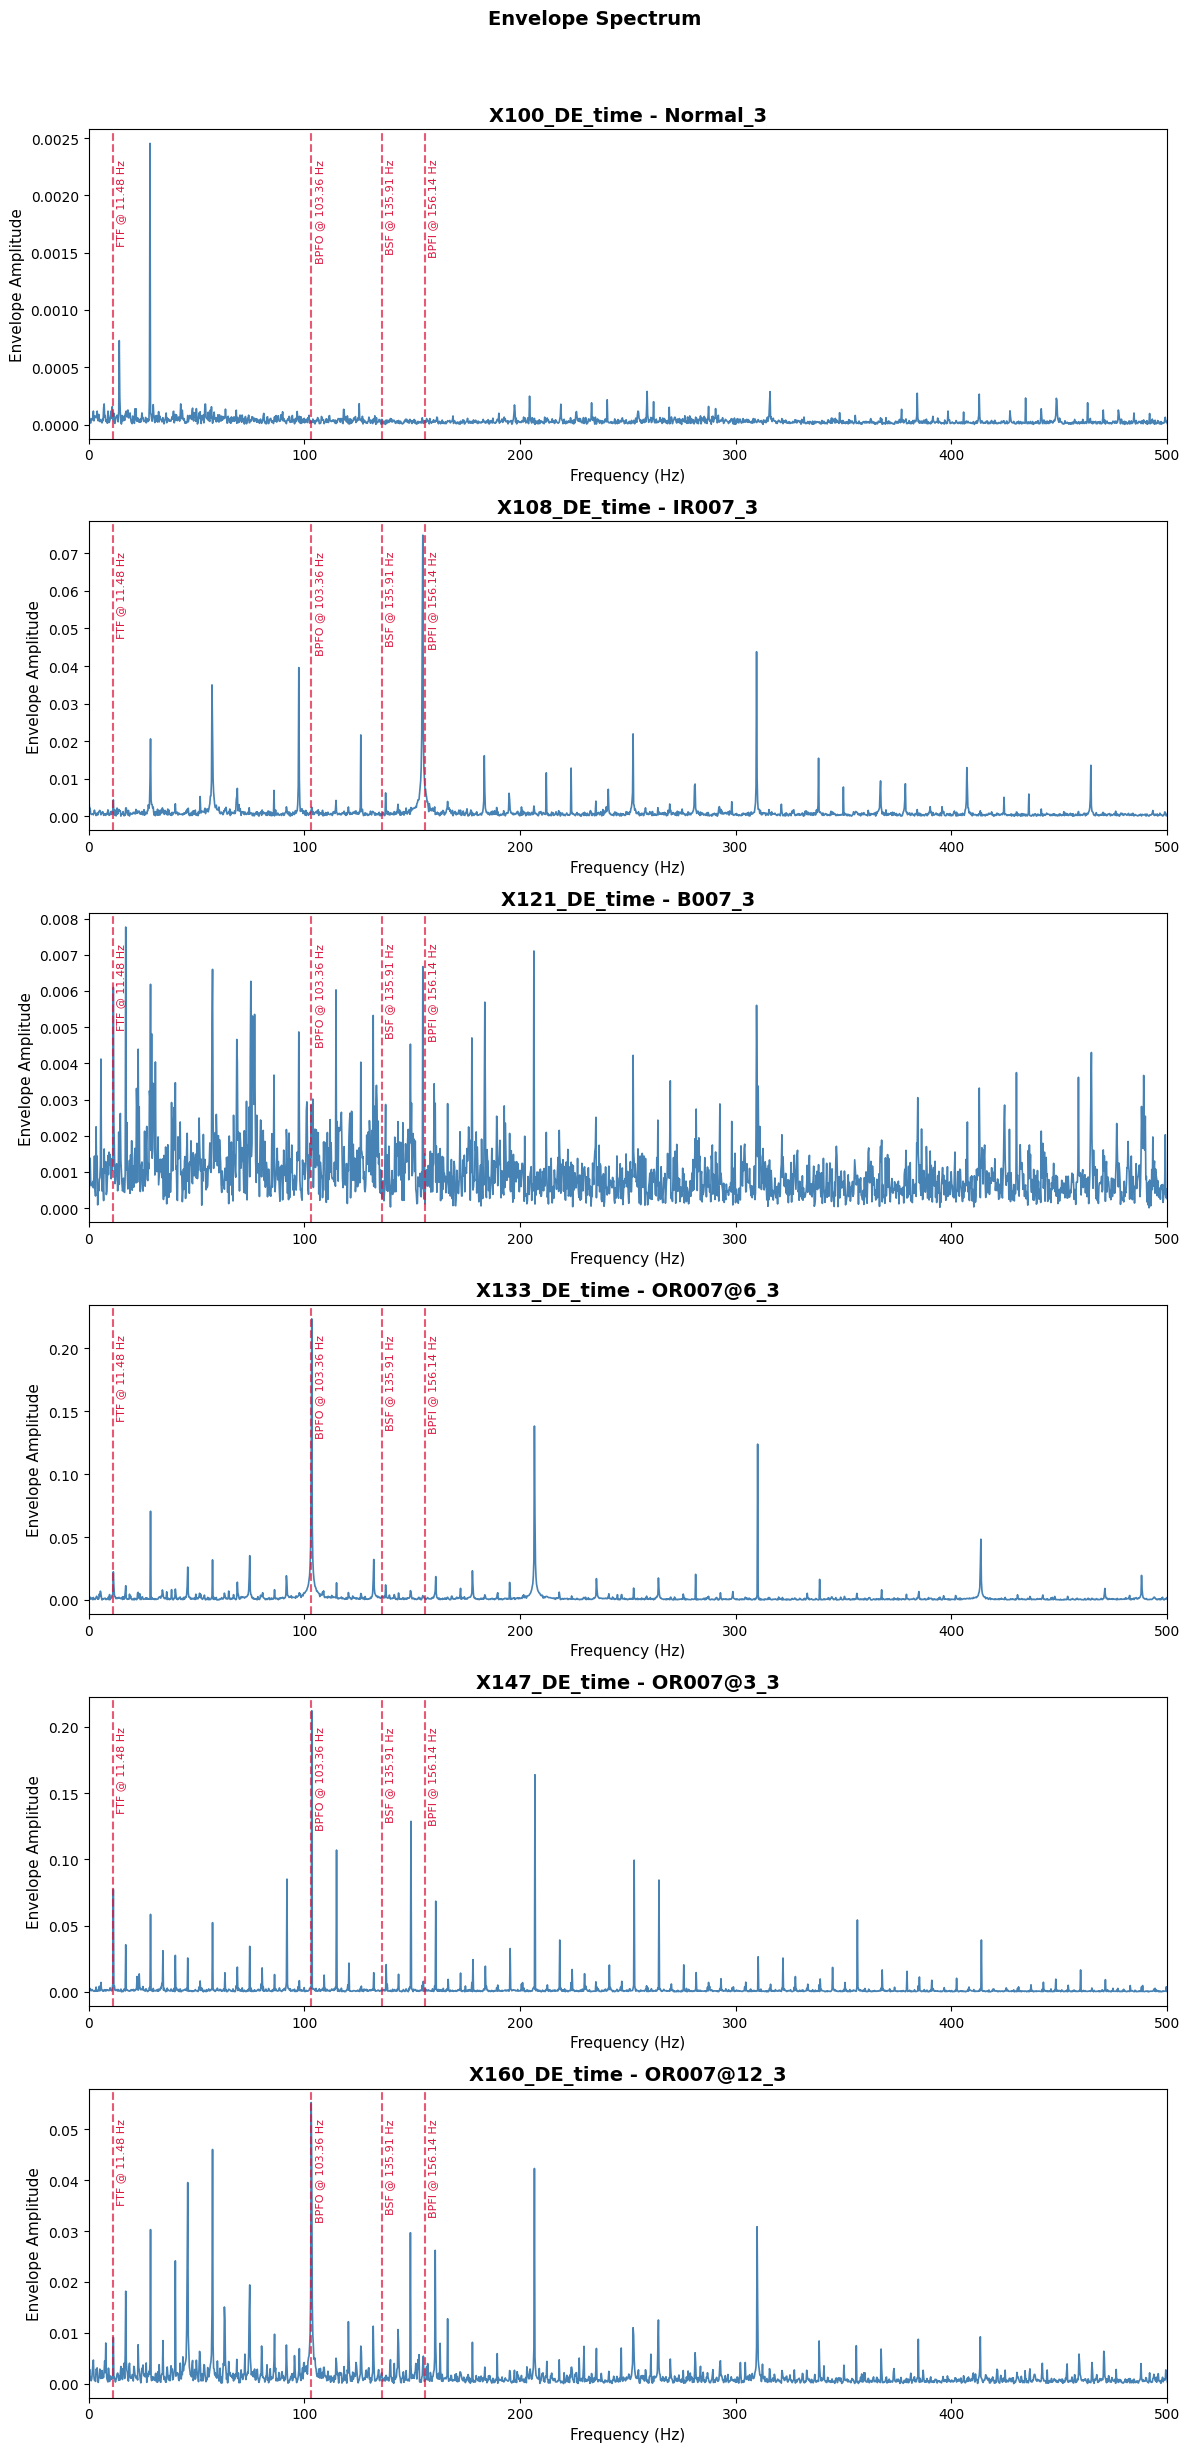

In [97]:
fig, axes = plt.subplots(6, 1, figsize=(12, 24))
axes = axes.flatten()

for (_, info), (idx, (key, data)) in zip(MAT_MAP.items(), enumerate(sorted(raw_data.items()))):
  ax = axes[idx]
  freqs, env = envelope_spectrum(data[: 4 * SAMPLING_RATE])

  ax.plot(freqs, env, linewidth=1.2, color="steelblue")
  ax.set_xlim(0, 500)
  ax.set_xlabel("Frequency (Hz)", fontsize=11)
  ax.set_ylabel("Envelope Amplitude", fontsize=11)

  ax.set_title(f"{key} - {info['name']}", fontsize=14, fontweight="bold")

  for name, info in DEFECT_FREQUENCIES.items():
    ax.axvline(info["value"] * RUNNING_FREQUENCY, color="crimson", linestyle="--", alpha=0.7)
    ax.text((info["value"]  * RUNNING_FREQUENCY) + 1.5, ax.get_ylim()[1] * 0.9, f"{name} @ {info["value"]  * RUNNING_FREQUENCY:.2f} Hz", rotation=90,
            verticalalignment="top", color="crimson", fontsize=8)

fig.suptitle("Envelope Spectrum",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

- The envelope spectrum peaks align with the theoretical fault frequencies. For example, strongest at BPFI for the inner-race file, at BPFO for the outer-race files, and is more spread out for the ball fault (which is
expected as ball faults strike both races, produce a less consistent signature). Physics predicts where the peaks should be, and the data
confirms it. <br>

- This is the classical signal-processing approach to bearing diagnostics. The deep-learning model in the rest of the notebook works directly from raw waveforms, so, no envelope, no bandpass, no fault-frequency knowledge. It aims to learn equivalent (or better) discriminative features end-to-end.

## Data processing

In [98]:
WINDOW_SIZE = 1024
# WINDOW_STRIDE = 512
WINDOW_STRIDE = 1024

TRAIN_FRACTION = 0.5
VAL_FRACTION = 0.25
TEST_FRACTION = 1.0 - TRAIN_FRACTION - VAL_FRACTION

print(f"Window: {WINDOW_SIZE} samples ({WINDOW_SIZE / SAMPLING_RATE * 1000:.1f} ms)")
print(f"Stride: {WINDOW_STRIDE} samples ({WINDOW_STRIDE / SAMPLING_RATE * 1000:.1f} ms, with {(1 - (WINDOW_STRIDE / WINDOW_SIZE))*100:.0f}% overlap)")

Window: 1024 samples (85.3 ms)
Stride: 1024 samples (85.3 ms, with 0% overlap)


- **No overlap** is intentional. With overlap, adjacent windows share samples, and a random train/test split would put near-duplicates of the
same signal in both, a leakage source that inflates accuracy. <br>

- Non-overlapping windows are combined with a **temporal split**, the first 50% of each recording is training, the next 25% validation, the last 25% test. Within-recording temporal contiguity is preserved; the model never sees test samples during training.

In [99]:
def extract_windows(raw_data, window_size = WINDOW_SIZE, window_stride = WINDOW_STRIDE):
  windows = []
  for i in range(0, len(raw_data) - window_size + 1, window_stride):
    window = raw_data[i : i + window_size]
    windows.append(window)

  return np.array(windows)

In [100]:
def normalize_windows(windows, epsilon = 1e-8):
    mean_window = windows.mean(axis=1, keepdims=True)
    std_window = windows.std(axis=1, keepdims=True)
    normalized = (windows - mean_window) / (std_window + epsilon)
    normalized = normalized.astype(np.float32)

    return normalized

In [101]:
def split_selected_data(selected_data, val_fraction = VAL_FRACTION, test_fraction = TEST_FRACTION):
    total_samples = len(selected_data)

    val_size = int(total_samples * val_fraction)
    test_size = int(total_samples * test_fraction)
    train_size = total_samples - val_size - test_size

    train_chunk = selected_data[:train_size]
    val_chunk = selected_data[train_size : train_size + val_size]
    test_chunk = selected_data[train_size + val_size :]

    return train_chunk, val_chunk, test_chunk

In [102]:
def build_windowed_dataset(
    selected_data,
    label_to_index,
    val_fraction = VAL_FRACTION,
    test_fraction = TEST_FRACTION,
    window_size = WINDOW_SIZE,
    window_stride = WINDOW_STRIDE,
    normalized = True,
    seed = 42
):

    train_windows_all = []
    train_labels_all = []
    val_windows_all = []
    val_labels_all = []
    test_windows_all = []
    test_labels_all = []

    for class_label, data in selected_data.items():
        class_index = label_to_index[class_label]

        train_chunk, val_chunk, test_chunk = split_selected_data(
            data,
            val_fraction=VAL_FRACTION,
            test_fraction=TEST_FRACTION,
        )

        train_windows = extract_windows(train_chunk, window_size, window_stride)
        val_windows = extract_windows(val_chunk, window_size, window_stride)
        test_windows = extract_windows(test_chunk, window_size, window_stride)

        if normalized:
          train_windows_normalized = normalize_windows(train_windows)
          val_windows_normalized = normalize_windows(val_windows)
          test_windows_normalized = normalize_windows(test_windows)

          train_labels = np.full(train_windows_normalized.shape[0], class_index, dtype=np.int64)
          val_labels = np.full(val_windows_normalized.shape[0], class_index, dtype=np.int64)
          test_labels = np.full(test_windows_normalized.shape[0], class_index, dtype=np.int64)

          train_windows_all.append(train_windows_normalized)
          train_labels_all.append(train_labels)
          val_windows_all.append(val_windows_normalized)
          val_labels_all.append(val_labels)
          test_windows_all.append(test_windows_normalized)
          test_labels_all.append(test_labels)

        else:
          train_labels = np.full(train_windows.shape[0], class_index, dtype=np.int64)
          val_labels = np.full(val_windows.shape[0], class_index, dtype=np.int64)
          test_labels = np.full(test_windows.shape[0], class_index, dtype=np.int64)

          train_windows_all.append(train_windows)
          train_labels_all.append(train_labels)
          val_windows_all.append(val_windows)
          val_labels_all.append(val_labels)
          test_windows_all.append(test_windows)
          test_labels_all.append(test_labels)

    x_train = np.concatenate(train_windows_all, axis=0)
    y_train = np.concatenate(train_labels_all, axis=0)
    x_val = np.concatenate(val_windows_all, axis=0)
    y_val = np.concatenate(val_labels_all, axis=0)
    x_test = np.concatenate(test_windows_all, axis=0)
    y_test = np.concatenate(test_labels_all, axis=0)

    rng = np.random.default_rng(seed)

    train_permutation = rng.permutation(x_train.shape[0])
    x_train = x_train[train_permutation]
    y_train = y_train[train_permutation]

    val_permutation = rng.permutation(x_val.shape[0])
    x_val = x_val[val_permutation]
    y_val = y_val[val_permutation]

    test_permutation = rng.permutation(x_test.shape[0])
    x_test = x_test[test_permutation]
    y_test = y_test[test_permutation]

    return {
        "train": (x_train, y_train),
        "val": (x_val, y_val),
        "test": (x_test, y_test),
    }

In [103]:
selected_keys = ['X100_DE_time', 'X108_DE_time', 'X121_DE_time', 'X160_DE_time']

selected_data = {}
for key in selected_keys:
  selected_data[key] = raw_data[key]

selected_data

{'X100_DE_time': array([ 0.01460308,  0.05444862,  0.10764554, ..., -0.02357354,
         0.00521538,  0.04777292]),
 'X108_DE_time': array([ 0.22269856,  0.09323776, -0.14651649, ..., -0.36125573,
         0.31138814,  0.17055689]),
 'X121_DE_time': array([ 0.09031393,  0.22497265, -0.10883154, ...,  0.02858858,
        -0.15934886, -0.01835517]),
 'X160_DE_time': array([ 0.16438435,  0.21506411, -0.22497265, ...,  0.01120802,
        -0.12507505, -0.02826371])}

- Training uses four classes — **Healthy**, **Inner race**, **Ball**, and **Outer race** — from `X100`, `X108`, `X121`, and `X160` respectively. <br>

- The other two outer-race files (`X133` @6 and `X147` @3) are dropped from training as they are the same fault type from different sensor
positions. However, they remain in the EDA above for comparison.

In [104]:
# Collect unique labels in order
unique_labels = []
for key in sorted(selected_data):
    mat_id = int(key.split('_')[0][1:])
    label = MAT_MAP[mat_id]['label']
    if label not in unique_labels:
        unique_labels.append(label)

# Map each selected_data key to its class index
LABEL_TO_INDEX = {}
for key in selected_data:
    mat_id = int(key.split('_')[0][1:])
    label = MAT_MAP[mat_id]['label']
    LABEL_TO_INDEX[key] = unique_labels.index(label)

In [105]:
data_splits = build_windowed_dataset(
    selected_data=selected_data,
    label_to_index=LABEL_TO_INDEX,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    val_fraction=VAL_FRACTION,
    test_fraction=TEST_FRACTION,
    normalized=True
)

for split_name, (split_x, split_y) in data_splits.items():
    print(f"{split_name: >5}: X shape = {split_x.shape}, y shape = {split_y.shape}")

train: X shape = (415, 1024), y shape = (415,)
  val: X shape = (206, 1024), y shape = (206,)
 test: X shape = (206, 1024), y shape = (206,)


### Data Split Distributions

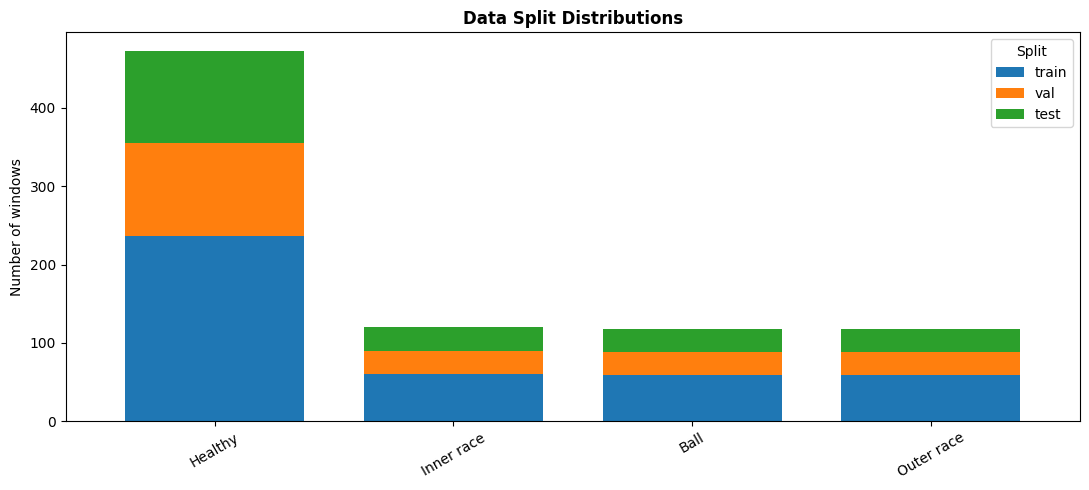

In [106]:
rows = []

for split_name, (_, split_y) in data_splits.items():
  counts = np.bincount(split_y, minlength=len(unique_labels))

  for class_index, class_label in enumerate(unique_labels):
    rows.append({
      "split": split_name,
      "class": class_label,
      "count": int(counts[class_index]),
    })

counts_df = pd.DataFrame(rows)

pivoted = counts_df.pivot(index="class", columns="split", values="count")
pivoted = pivoted.reindex(unique_labels)
pivoted = pivoted[["train", "val", "test"]]

fig, ax = plt.subplots(figsize=(11, 5))
# colors = ["#003f5c", "#bc5090", "#ffa600"]

pivoted.plot(kind="bar", stacked=True, ax=ax, width=0.75)

ax.set_ylabel("Number of windows")
ax.set_xlabel("")
ax.set_title("Data Split Distributions", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Split")

fig.tight_layout()
plt.show()

## Dataset

In [107]:
if torch.cuda.is_available():
    device = torch.device("cuda")

else:
    device = torch.device("cpu")

In [108]:
class CWRUWindowDataset(Dataset):

    def __init__(self, windows, labels):
        self.windows = torch.from_numpy(windows).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return self.windows.shape[0]

    def __getitem__(self, index):
        window = self.windows[index]
        window = window.unsqueeze(0)
        label = self.labels[index]

        return window, label

In [109]:
train_dataset = CWRUWindowDataset(data_splits['train'][0], data_splits['train'][1])
val_dataset = CWRUWindowDataset(data_splits['val'][0], data_splits['val'][1])
test_dataset = CWRUWindowDataset(data_splits['test'][0], data_splits['test'][1])

In [110]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
)

In [111]:
example_batch_inputs, example_batch_labels = next(iter(train_loader))
print(f"Batch input shape: {tuple(example_batch_inputs.shape)}")
print(f"Batch input dtype: {example_batch_inputs.dtype}")
print(f"Batch label shape: {tuple(example_batch_labels.shape)}")
print(f"Batch label dtype: {example_batch_labels.dtype}")

Batch input shape: (128, 1, 1024)
Batch input dtype: torch.float32
Batch label shape: (128,)
Batch label dtype: torch.int64


## CNN-Transformer

In [112]:
class GaussianNoise(nn.Module):
    def __init__(self, sigma = 0.1):
        super().__init__()
        self.sigma = sigma

    def forward(self, x):
        if self.training and self.sigma > 0:
            return x + torch.randn_like(x) * self.sigma
        return x

### Convolutional block

In [113]:
class ConvolutionalBlock(nn.Module):

    def __init__(
        self,
        in_channels = 1,
        intermediate_channels = (32, 64),
        out_channels = 128,
        kernel_size = 7,
    ):
        super().__init__()

        padding = kernel_size // 2

        self.block_1 = nn.Sequential(
            nn.Conv1d(in_channels, intermediate_channels[0], kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(intermediate_channels[0]),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),
        )

        self.block_2 = nn.Sequential(
            nn.Conv1d(intermediate_channels[0], intermediate_channels[1], kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(intermediate_channels[1]),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),
        )

        self.block_3 = nn.Sequential(
            nn.Conv1d(intermediate_channels[1], out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4),
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)

        return x

### Positional encoding

In [114]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model = 128, max_length= 2048):
        super().__init__()

        encodings = torch.zeros(max_length, d_model)
        positions = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)

        even_dimension_indices = torch.arange(0, d_model, 2, dtype=torch.float)
        scaling_factor = -math.log(10000.0) / d_model
        frequency_scale = torch.exp(even_dimension_indices * scaling_factor)

        encodings[:, 0::2] = torch.sin(positions * frequency_scale)
        encodings[:, 1::2] = torch.cos(positions * frequency_scale)
        encodings = encodings.unsqueeze(0)

        self.register_buffer("positional_encoding", encodings)

    def forward(self, x):
        sequence_length = x.size(1)
        positional_slice = self.positional_encoding[:, :sequence_length, :]
        x = x + positional_slice

        return x

### CNN-Transformer

In [115]:
class CNNTransformer(nn.Module):
    def __init__(
        self,
        number_of_classes = 4,
        d_model = 128,
        number_of_heads = 4,
        number_of_transformer_layers = 4,
        dim_feedforward = 256,
        dropout = 0.3,
        sigma=0.3
    ):
        super().__init__()

        self.gaussian_noise = GaussianNoise(sigma=sigma)
        self.convolutional_block = ConvolutionalBlock(in_channels=1, out_channels=d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model)

        single_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=number_of_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )

        self.transformer_encoder = nn.TransformerEncoder(
            single_encoder_layer,
            num_layers=number_of_transformer_layers,
        )

        self.classifier = nn.Linear(d_model, number_of_classes)

    def forward(self, x):
        gaussian_noise = self.gaussian_noise(x)
        convolutional_features = self.convolutional_block(gaussian_noise)
        sequence_features = convolutional_features.transpose(1, 2)    ## (batch_size, sequence_length, d_model), d_model = number of channels from CNN
        positionally_encoded_sequence = self.positional_encoding(sequence_features)
        transformer_output_sequence = self.transformer_encoder(positionally_encoded_sequence)
        pooled_features = transformer_output_sequence.mean(dim=1)
        logits = self.classifier(pooled_features)

        return logits

    def extract_embedding(self, x):
        gaussian_noise = self.gaussian_noise(x)
        convolutional_features = self.convolutional_block(gaussian_noise)
        sequence_features = convolutional_features.transpose(1, 2)
        positionally_encoded_sequence = self.positional_encoding(sequence_features)
        transformer_output_sequence = self.transformer_encoder(positionally_encoded_sequence)
        pooled_features = transformer_output_sequence.mean(dim=1)

        return pooled_features

## Smoke Test

In [116]:
def run_smoke_test():
    smoke_test_batch_size = 4
    smoke_test_sequence_length = 1024
    smoke_test_number_of_classes = 4

    dummy_input = torch.randn(smoke_test_batch_size, 1, smoke_test_sequence_length)
    smoke_test_model = CNNTransformer(number_of_classes=smoke_test_number_of_classes)
    smoke_test_model.eval()

    with torch.no_grad():
        output_logits = smoke_test_model(dummy_input)

    expected_shape = (smoke_test_batch_size, smoke_test_number_of_classes)
    actual_shape = tuple(output_logits.shape)
    assert actual_shape == expected_shape, (
        f"Smoke test FAILED: expected {expected_shape}, got {actual_shape}"
    )

    total_parameter_count = 0
    for parameter_tensor in smoke_test_model.parameters():
        total_parameter_count = total_parameter_count + parameter_tensor.numel()

    print(f"Smoke test passed.")
    print(f"Input shape: {tuple(dummy_input.shape)}")
    print(f"Output shape: {actual_shape}")
    print(f"Parameters: {total_parameter_count:,}")


run_smoke_test()

Smoke test passed.
Input shape: (4, 1, 1024)
Output shape: (4, 4)
Parameters: 603,012


## Training

In [117]:
def train_one_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
    device,
):
    model.train()

    total_loss_weighted = 0.0
    total_correct_predictions = 0
    total_examples = 0

    for batch_inputs, batch_labels in data_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        batch_logits = model(batch_inputs)
        batch_loss = loss_function(batch_logits, batch_labels)
        batch_loss.backward()

        optimizer.step()

        examples_in_batch = batch_inputs.size(0)      ## current batch size
        total_loss_weighted += batch_loss.item() * examples_in_batch

        predicted_classes = batch_logits.argmax(dim=1)
        correct_in_batch = (predicted_classes == batch_labels).sum().item()
        total_correct_predictions += correct_in_batch
        total_examples += examples_in_batch

    average_loss = total_loss_weighted / total_examples
    accuracy = total_correct_predictions / total_examples

    return average_loss, accuracy


def evaluate(
    model,
    data_loader,
    loss_function,
    device,
):
    model.eval()

    total_loss_weighted = 0.0
    total_correct_predictions = 0
    total_examples = 0

    with torch.no_grad():
        for batch_inputs, batch_labels in data_loader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)

            batch_logits = model(batch_inputs)
            batch_loss = loss_function(batch_logits, batch_labels)

            examples_in_batch = batch_inputs.size(0)      ## current batch size
            total_loss_weighted += batch_loss.item() * examples_in_batch

            predicted_classes = batch_logits.argmax(dim=1)
            correct_in_batch = (predicted_classes == batch_labels).sum().item()

            total_correct_predictions += correct_in_batch
            total_examples += examples_in_batch

    average_loss = total_loss_weighted / total_examples
    average_accuracy = total_correct_predictions / total_examples

    return average_loss, average_accuracy

In [118]:
NUMBER_OF_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Training on device: {device}")

model = CNNTransformer().to(device)

loss_function = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUMBER_OF_EPOCHS,
)

best_validation_accuracy = 0.0
best_model_state_dict = None
history = []

for epoch_index in range(1, NUMBER_OF_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        loss_function=loss_function,
        optimizer=optimizer,
        device=device,
    )

    validation_loss, validation_accuracy = evaluate(
        model=model,
        data_loader=val_loader,
        loss_function=loss_function,
        device=device,
    )

    current_lr = lr_scheduler.get_last_lr()[0]
    lr_scheduler.step()

    epoch_record = {
        "epoch": epoch_index,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_loss": validation_loss,
        "validation_accuracy": validation_accuracy,
    }

    history.append(epoch_record)

    print(
        f"Epoch {epoch_index:>2d}/{NUMBER_OF_EPOCHS} | "
        f"train loss {train_loss:.4f}  accuracy {train_accuracy:.4f} | "
        f"validation loss {validation_loss:.4f}  accuracy {validation_accuracy:.4f}"
    )

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_state_dict = {}
        for parameter_name, parameter_tensor in model.state_dict().items():
            best_state_dict[parameter_name] = parameter_tensor.detach().cpu().clone()

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

test_loss, test_accuracy = evaluate(
    model=model,
    data_loader=test_loader,
    loss_function=loss_function,
    device=device,
)

print(f"\nBest validation accuracy: {best_validation_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Training on device: cuda
Epoch  1/15 | train loss 0.8517  accuracy 0.5547 | validation loss 0.6564  accuracy 0.5728
Epoch  2/15 | train loss 0.2154  accuracy 0.9948 | validation loss 0.4017  accuracy 0.8350
Epoch  3/15 | train loss 0.0536  accuracy 1.0000 | validation loss 0.2990  accuracy 0.8592
Epoch  4/15 | train loss 0.0319  accuracy 1.0000 | validation loss 0.0618  accuracy 0.9854
Epoch  5/15 | train loss 0.0112  accuracy 1.0000 | validation loss 0.0106  accuracy 1.0000
Epoch  6/15 | train loss 0.0076  accuracy 1.0000 | validation loss 0.0054  accuracy 1.0000
Epoch  7/15 | train loss 0.0074  accuracy 1.0000 | validation loss 0.0047  accuracy 1.0000
Epoch  8/15 | train loss 0.0047  accuracy 1.0000 | validation loss 0.0040  accuracy 1.0000
Epoch  9/15 | train loss 0.0039  accuracy 1.0000 | validation loss 0.0038  accuracy 1.0000
Epoch 10/15 | train loss 0.0036  accuracy 1.0000 | validation loss 0.0039  accuracy 1.0000
Epoch 11/15 | train loss 0.0034  accuracy 1.0000 | validation los

## Plots

### Training curves

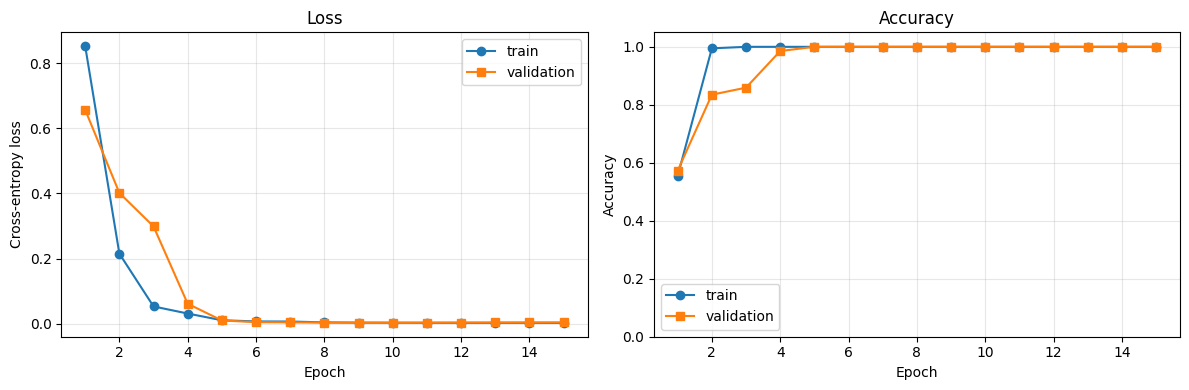

In [119]:
processed_history = {
    "train_loss": [epoch["train_loss"] for epoch in history],
    "validation_loss": [epoch["validation_loss"] for epoch in history],
    "train_accuracy": [epoch["train_accuracy"] for epoch in history],
    "validation_accuracy": [epoch["validation_accuracy"] for epoch in history],
}

number_of_epochs_run = len(processed_history["train_loss"])
epoch_axis = np.arange(1, number_of_epochs_run + 1)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

loss_axis = axes[0]
loss_axis.plot(epoch_axis, processed_history["train_loss"], label="train", marker="o")
loss_axis.plot(epoch_axis, processed_history["validation_loss"], label="validation", marker="s")
loss_axis.set_xlabel("Epoch")
loss_axis.set_ylabel("Cross-entropy loss")
loss_axis.set_title("Loss")
loss_axis.grid(True, alpha=0.3)
loss_axis.legend()

accuracy_axis = axes[1]
accuracy_axis.plot(epoch_axis, processed_history["train_accuracy"], label="train", marker="o")
accuracy_axis.plot(epoch_axis, processed_history["validation_accuracy"], label="validation", marker="s")
accuracy_axis.set_xlabel("Epoch")
accuracy_axis.set_ylabel("Accuracy")
accuracy_axis.set_title("Accuracy")
accuracy_axis.set_ylim(0.0, 1.05)
accuracy_axis.grid(True, alpha=0.3)
accuracy_axis.legend()

figure.tight_layout()
plt.show()

- End-to-end learning from raw waveforms reaches **99.51% test accuracy** with no hand-crafted features, so, no envelope spectrum, no fault-frequency computation, no bandpass filtering. <br>

- **The result is consistent with the literature, not surprising.** CWRU under a single operating condition is a benchmark where modern deep models routinely exceed 99%. <br>

Limitation: <br>
- 99.51% accuracy on CWRU under a single operating condition does not demonstrate the model is *good*, it just demonstrates the task is *easy* under matched train / test conditions.

### Confusion matrix and per-class metrics

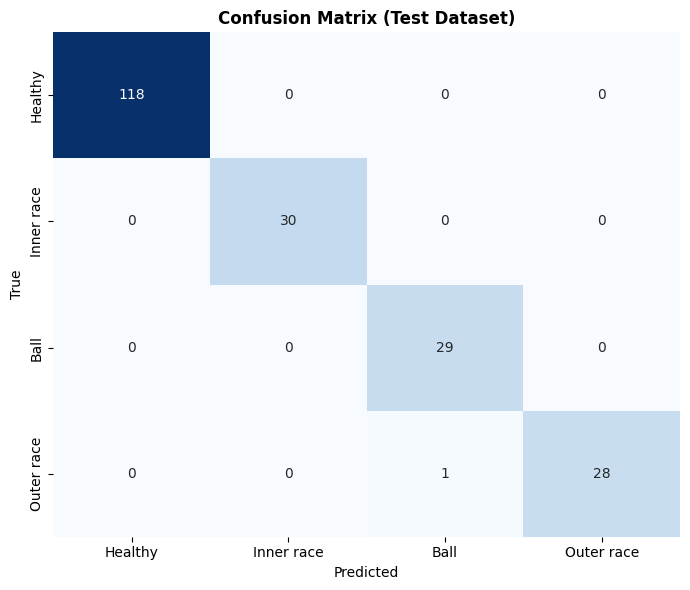


Per-class metrics (test dataset):

              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000       118
  Inner race     1.0000    1.0000    1.0000        30
        Ball     0.9667    1.0000    0.9831        29
  Outer race     1.0000    0.9655    0.9825        29

    accuracy                         0.9951       206
   macro avg     0.9917    0.9914    0.9914       206
weighted avg     0.9953    0.9951    0.9951       206



In [120]:
torch.manual_seed(42)

model.eval()
prediction_chunks = []
label_chunks = []

with torch.no_grad():
    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device, non_blocking=True)
        batch_logits = model(batch_inputs)
        batch_predictions = batch_logits.argmax(dim=1)

        prediction_chunks.append(batch_predictions.cpu().numpy())
        label_chunks.append(batch_labels.numpy())

test_predictions = np.concatenate(prediction_chunks, axis=0)
test_labels = np.concatenate(label_chunks, axis=0)

cm = confusion_matrix(test_labels, test_predictions)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=unique_labels,
    yticklabels=unique_labels,
    cbar=False,
    ax=ax,
)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Test Dataset)", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nPer-class metrics (test dataset):\n")
print(classification_report(
    test_labels,
    test_predictions,
    target_names=unique_labels,
    digits=4,
))

- A single misclassification on the test set, an *Outer race* window was predicted as *Ball*.

### t-SNE

Embeddings shape: (206, 128)


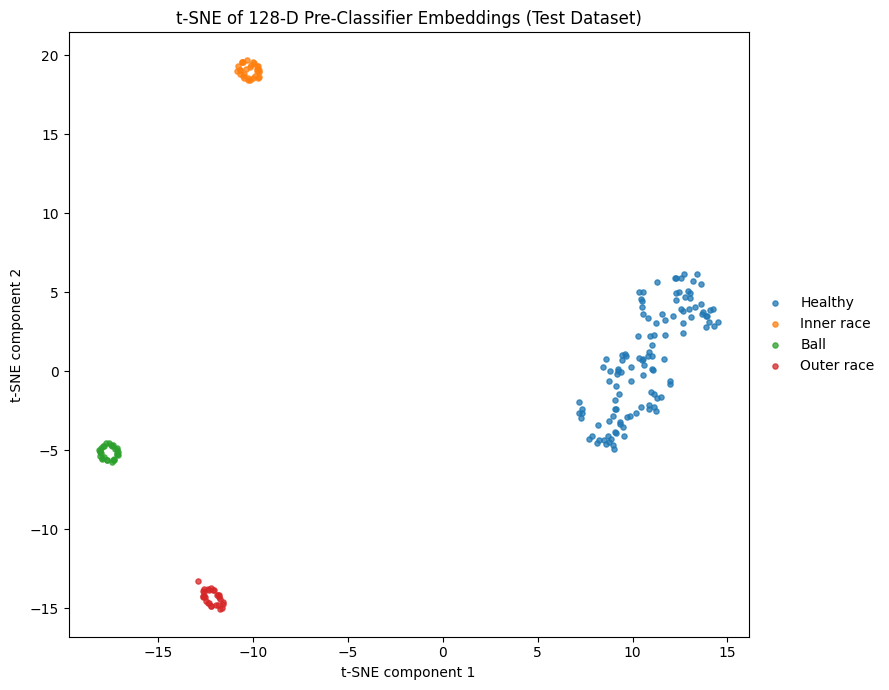

In [121]:
torch.manual_seed(42)

model.eval()
embedding_chunks = []
label_chunks = []

with torch.no_grad():
    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device, non_blocking=True)
        batch_embeddings = model.extract_embedding(batch_inputs)
        embedding_chunks.append(batch_embeddings.cpu().numpy())
        label_chunks.append(batch_labels.numpy())

test_embeddings_128d = np.concatenate(embedding_chunks, axis=0)
test_embedding_labels = np.concatenate(label_chunks, axis=0)

print(f"Embeddings shape: {test_embeddings_128d.shape}")

tsne_projector = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto",
)

test_embeddings_2d = tsne_projector.fit_transform(test_embeddings_128d)

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("tab10", 4)

for class_index in range(4):
    mask_for_class = test_embedding_labels == class_index
    ax.scatter(
        test_embeddings_2d[mask_for_class, 0],
        test_embeddings_2d[mask_for_class, 1],
        s=14,
        alpha=0.75,
        color=palette[class_index],
        label=unique_labels[class_index],
    )

ax.set_title("t-SNE of 128-D Pre-Classifier Embeddings (Test Dataset)")
ax.set_xlabel("t-SNE component 1")
ax.set_ylabel("t-SNE component 2")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)

plt.tight_layout()
plt.show()

- The t-SNE projection of the 128-D pre-classifier embeddings shows clear class separation, indicating the model has learned a discriminative
representation rather than memorizing window identities.

## References

1. https://www.nature.com/articles/s41598-025-95895-x
2. https://www.mdpi.com/2075-1702/13/8/737
3. https://arxiv.org/pdf/2407.14625v1
4. https://ieeexplore.ieee.org/document/9078761
